# EDA — The Global AI/ML/Data Science Salary for 2025

**Objetivo del proyecto:** estimar `salary_in_usd` (regresión) para roles de datos e IA,
como referencia de mercado en procesos de compensación/atracción de talento.

**Fuente:** [Kaggle — The Global AI/ML/Data Science Salary for 2025](https://www.kaggle.com/datasets/samithsachidanandan/the-global-ai-ml-data-science-salary-for-2025).
Ficha completa del dataset en `docs/dataset.md`, parámetros en `configs/config.yaml`.

**Alcance de este notebook:** distribución de la variable objetivo, faltantes, atípicos,
correlaciones, y las conclusiones que van a guiar el preprocesamiento (actividad 5) y la
partición train/validación.


In [1]:
import hashlib
import io
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import yaml
from scipy.stats import skew

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

## 1. Carga de datos

La descarga es reproducible (mismo endpoint público verificado en `docs/dataset.md`) y usa `data/raw/` como caché local. La automatización formal como task de Prefect (reintentos, `metadata.json`) se implementa en la actividad 4; aquí solo se necesita el dato en memoria para explorarlo.

In [2]:
REPO_ROOT = Path.cwd().parent
with open(REPO_ROOT / "configs" / "config.yaml", encoding="utf-8") as f:
    config = yaml.safe_load(f)

dataset_cfg = config["dataset"]
raw_path = REPO_ROOT / config["paths"]["raw"] / dataset_cfg["raw_filename"]
target = dataset_cfg["target_column"]
leakage_cols = dataset_cfg["leakage_columns"]

dataset_cfg

{'name': 'global-ai-ml-data-science-salary-2025',
 'kaggle_page': 'https://www.kaggle.com/datasets/samithsachidanandan/the-global-ai-ml-data-science-salary-for-2025',
 'source_url': 'https://www.kaggle.com/api/v1/datasets/download/samithsachidanandan/the-global-ai-ml-data-science-salary-for-2025',
 'raw_filename': 'salaries.csv',
 'target_column': 'salary_in_usd',
 'leakage_columns': ['salary', 'salary_currency']}

In [3]:
def descargar_dataset_si_falta(url: str, destino: Path, nombre_csv_en_zip: str) -> Path:
    """Descarga el dataset solo si no está ya en caché local (data/raw/ no se versiona)."""
    if destino.exists():
        print(f"Ya existe en caché: {destino}")
        return destino
    destino.parent.mkdir(parents=True, exist_ok=True)
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        destino.write_bytes(zf.read(nombre_csv_en_zip))
    print(f"Descargado y guardado en: {destino}")
    return destino


descargar_dataset_si_falta(
    dataset_cfg["source_url"], raw_path, dataset_cfg["raw_filename"]
)
print(f"sha256: {hashlib.sha256(raw_path.read_bytes()).hexdigest()}")

df = pd.read_csv(raw_path)
df.shape

Ya existe en caché: C:\Users\juani\Downloads\proyecto_final\data\raw\salaries.csv
sha256: 6435133e3962979cbb86d16e683190e01fc3124dc32bc374ccacb3bd73c97178


(88584, 11)

In [4]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,MI,FT,Customer Success Manager,57000,EUR,60000,NL,50,NL,L
1,2025,SE,FT,Engineer,165000,USD,165000,US,0,US,M
2,2025,SE,FT,Engineer,109000,USD,109000,US,0,US,M
3,2025,SE,FT,Applied Scientist,294000,USD,294000,US,0,US,M
4,2025,SE,FT,Applied Scientist,137600,USD,137600,US,0,US,M


In [5]:
df.dtypes

work_year             int64
experience_level        str
employment_type         str
job_title               str
salary                int64
salary_currency         str
salary_in_usd         int64
employee_residence      str
remote_ratio          int64
company_location        str
company_size            str
dtype: object

## 2. Calidad de datos: faltantes y duplicados

In [6]:
df.isnull().sum().to_frame(name="nulos")

,nulos
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


**Faltantes:** cero valores nulos en las 88.584 filas × 11 columnas — coincide con el perfil documentado en `docs/dataset.md`. No se requieren imputaciones.

In [7]:
n_dup_extra = df.duplicated().sum()
n_dup_involved = df.duplicated(keep=False).sum()
print(
    f"Filas duplicadas exactas (se perderían con keep='first'): {n_dup_extra} ({n_dup_extra / len(df):.1%})"
)
print(
    f"Filas involucradas en algún grupo de duplicados: {n_dup_involved} ({n_dup_involved / len(df):.1%})"
)

Filas duplicadas exactas (se perderían con keep='first'): 44340 (50.1%)
Filas involucradas en algún grupo de duplicados: 57669 (65.1%)


In [8]:
# ¿La duplicación es esperable? Comparamos contra el espacio combinatorio de las
# columnas categóricas/numéricas (sin salary/salary_currency, que sí varían poco entre sí).
cols_sin_salario = [
    c for c in df.columns if c not in ("salary", "salary_currency", target)
]
combinaciones_unicas = df[cols_sin_salario].drop_duplicates().shape[0]
print(f"Combinaciones únicas de {cols_sin_salario}:")
print(f"{combinaciones_unicas} combinaciones distintas de {len(df)} filas")

Combinaciones únicas de ['work_year', 'experience_level', 'employment_type', 'job_title', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']:
4167 combinaciones distintas de 88584 filas


In [9]:
(
    df[df.duplicated(keep=False)]
    .groupby(list(df.columns))
    .size()
    .reset_index(name="conteo")
    .sort_values("conteo", ascending=False)
    .head(10)
)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,conteo
8104,2024,SE,FT,Data Scientist,160000,USD,160000,US,100,US,M,182
7909,2024,SE,FT,Data Scientist,110000,USD,110000,US,100,US,M,168
9458,2024,SE,FT,Machine Learning Researcher,110000,USD,110000,US,100,US,M,161
9461,2024,SE,FT,Machine Learning Researcher,160000,USD,160000,US,100,US,M,161
2921,2024,MI,FT,Applied Scientist,136000,USD,136000,US,0,US,L,113
2931,2024,MI,FT,Applied Scientist,222200,USD,222200,US,0,US,L,112
6214,2024,SE,FT,Applied Scientist,160000,USD,160000,US,100,US,M,108
6188,2024,SE,FT,Applied Scientist,110000,USD,110000,US,100,US,M,107
10543,2024,SE,FT,Software Engineer,180000,USD,180000,US,0,US,M,95
10599,2024,SE,FT,Software Engineer,200000,USD,200000,US,0,US,M,86


**Interpretación de los duplicados:** hay solo ~4.167 combinaciones distintas de
`work_year` + categóricas + `remote_ratio` para 88.584 filas, y los salarios reportados
tienden a ser cifras "redondas" (160.000, 110.000, etc.). Con un espacio de perfiles tan
acotado y ~88 mil encuestas, es estadísticamente esperable que muchas personas con el
mismo perfil (mismo año, seniority, cargo, país, modalidad remota, tamaño de empresa)
reporten el mismo salario redondeado — **no es un error de carga de datos**, sino
observaciones repetidas legítimas de una encuesta agregada.

**Dato importante para la partición temporal:** la comparación de duplicados ya incluye
`work_year`, así que ningún grupo duplicado cruza entre 2024 y 2025 — la partición
train/validación por año **no sufre fuga de información por duplicados**.

**Decisión:** no eliminar los duplicados (perderíamos señal real sobre qué combinaciones
de perfil son más comunes). Si más adelante el equipo agrega validación cruzada aleatoria
dentro de `train` (≤2024), tenerlo en cuenta: filas idénticas podrían caer en folds
distintos e inflar artificialmente la métrica.


## 3. Variable objetivo: `salary_in_usd`

In [10]:
df[target].describe()

count     88584.000000
mean     157567.798417
std       73531.373158
min       15000.000000
25%      106097.250000
50%      146307.000000
75%      198600.000000
max      800000.000000
Name: salary_in_usd, dtype: float64

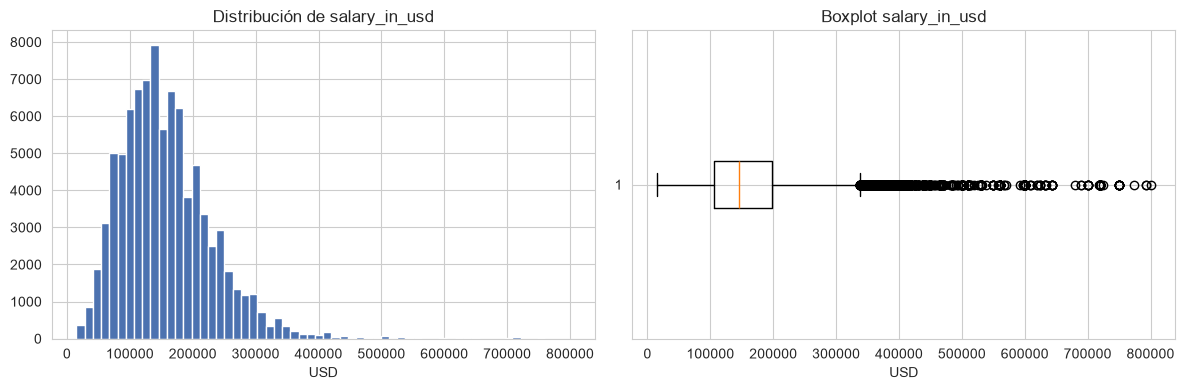

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df[target], bins=60, color="#4C72B0")
axes[0].set_title("Distribución de salary_in_usd")
axes[0].set_xlabel("USD")
axes[1].boxplot(df[target], orientation="horizontal")
axes[1].set_title("Boxplot salary_in_usd")
axes[1].set_xlabel("USD")
plt.tight_layout()
plt.show()

skew(salary_in_usd)          = 1.322
skew(log1p(salary_in_usd))   = -0.518


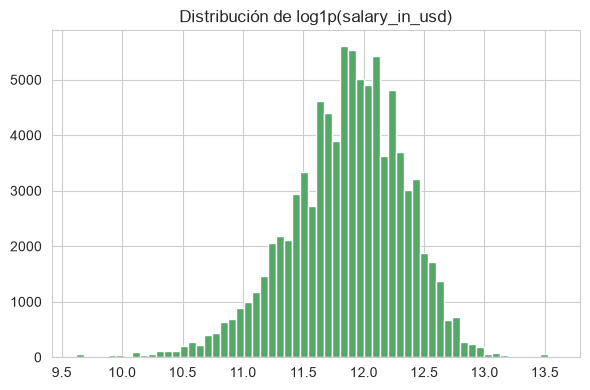

In [12]:
log_target = np.log1p(df[target])
print(f"skew(salary_in_usd)          = {skew(df[target]):.3f}")
print(f"skew(log1p(salary_in_usd))   = {skew(log_target):.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(log_target, bins=60, color="#55A868")
ax.set_title("Distribución de log1p(salary_in_usd)")
plt.tight_layout()
plt.show()

**Interpretación:** cola derecha pesada confirmada (`skew` = 1.32; mínimo 15.000, mediana
146.307, máximo 800.000). `log1p` reduce la magnitud de la asimetría a -0.52, una mejora
considerable aunque no perfecta.

**Decisión:** probar `log1p(salary_in_usd)` como variante de target en el entrenamiento
(actividad 6-7), siempre **destransformando con `expm1` antes de calcular el RMSE en USD**
— esa es la métrica de negocio acordada en `docs/dataset.md`, y reportar el error en escala
logarítmica sería un resultado no comparable/engañoso.


## 4. Atípicos

In [13]:
q1, q3 = df[target].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers_bajos = df[target] < lower
outliers_altos = df[target] > upper

print(f"Límites IQR (k=1.5): [{lower:.0f}, {upper:.0f}]")
print(f"Atípicos bajos:  {outliers_bajos.sum()} ({outliers_bajos.mean():.2%})")
print(f"Atípicos altos:  {outliers_altos.sum()} ({outliers_altos.mean():.2%})")
print(
    f"p1={df[target].quantile(0.01):.0f}  p99={df[target].quantile(0.99):.0f}  máx={df[target].max():.0f}"
)

Límites IQR (k=1.5): [-32657, 337354]
Atípicos bajos:  0 (0.00%)
Atípicos altos:  1750 (1.98%)
p1=37500  p99=375000  máx=800000


**Interpretación:** no hay atípicos bajos (el límite inferior de IQR es negativo; el
salario mínimo real, 15.000 USD, es válido). Hay **1.750 atípicos altos (1.98%)**, todos
por encima de 337.354 USD — consistentes con roles ejecutivos/senior en mercados de alta
remuneración, no con errores de captura.

**Decisión:** no eliminar estos registros — son observaciones reales y el caso de negocio
(estimar salario de referencia) necesita que el modelo también funcione para roles senior
bien pagados. Se mantiene RMSE como métrica principal (sensible a estos valores, refleja
el costo real de un error grande) y MAE como apoyo (más robusta a la cola). Si el baseline
muestra error concentrado en la cola alta, se puede revisar un filtro o ponderación en la
actividad 6.


## 5. Variables categóricas

In [14]:
categoricas = [
    "experience_level",
    "employment_type",
    "job_title",
    "employee_residence",
    "remote_ratio",
    "company_location",
    "company_size",
]
pd.Series({c: df[c].nunique() for c in categoricas}, name="cardinalidad").to_frame()

,cardinalidad
experience_level,4
employment_type,4
job_title,312
employee_residence,96
remote_ratio,3
company_location,90
company_size,3


In [15]:
for c in ["experience_level", "employment_type", "remote_ratio", "company_size"]:
    print(f"\n-- {c} --")
    print(df[c].value_counts(normalize=True).round(4))


-- experience_level --
experience_level
SE    0.5825
MI    0.3020
EN    0.0946
EX    0.0210
Name: proportion, dtype: float64

-- employment_type --
employment_type
FT    0.9947
PT    0.0026
CT    0.0025
FL    0.0002
Name: proportion, dtype: float64

-- remote_ratio --
remote_ratio
0      0.7855
100    0.2112
50     0.0033
Name: proportion, dtype: float64

-- company_size --
company_size
M    0.9671
L    0.0305
S    0.0024
Name: proportion, dtype: float64


In [16]:
vc_job = df["job_title"].value_counts()
print("Top 10 job_title:")
print(vc_job.head(10))
print(
    f"\nTítulos con menos de 30 registros: {(vc_job < 30).sum()} de {len(vc_job)} "
    f"({vc_job[vc_job < 30].sum()} filas afectadas, {vc_job[vc_job < 30].sum() / len(df):.1%})"
)

Top 10 job_title:
job_title
Data Scientist               13156
Data Engineer                10883
Software Engineer             9596
Data Analyst                  8652
Machine Learning Engineer     6443
Engineer                      5344
Manager                       3488
Research Scientist            2553
Analyst                       2066
Applied Scientist             1778
Name: count, dtype: int64

Títulos con menos de 30 registros: 194 de 312 (1552 filas afectadas, 1.8%)


In [17]:
print("employee_residence — top 5 (concentración):")
print(df["employee_residence"].value_counts(normalize=True).head(5).round(4))
print("\ncompany_location — top 5 (concentración):")
print(df["company_location"].value_counts(normalize=True).head(5).round(4))

employee_residence — top 5 (concentración):
employee_residence
US    0.8998
CA    0.0362
GB    0.0291
AU    0.0034
DE    0.0030
Name: proportion, dtype: float64

company_location — top 5 (concentración):
company_location
US    0.9004
CA    0.0362
GB    0.0292
AU    0.0034
DE    0.0031
Name: proportion, dtype: float64


**Interpretación:**
- `employment_type` está dominado por `FT` (99.5%); `PT`/`CT`/`FL` casi no tienen muestra.
- `remote_ratio=50` es raro (0.33% de los datos) frente a 0 y 100.
- `company_size` está dominado por `M` (96.7%).
- `job_title` tiene 312 categorías; 194 de ellas (62%) tienen menos de 30 registros
  (1.8% de las filas) — cola larga que puede generar columnas dummy ruidosas con one-hot puro.
- ~90% de `employee_residence` y `company_location` es EE. UU. — el dataset no es
  representativo a nivel global (ya documentado como limitación en `docs/dataset.md`).

**Decisión (a implementar en la actividad 5 — preprocesamiento):**
- `job_title`: agrupar categorías poco frecuentes (< 30 registros) en `"Other"`, o usar
  encoding de frecuencia/target en vez de one-hot puro para no explotar la dimensionalidad.
- `employee_residence` / `company_location`: agrupar en EE. UU. vs. resto (o top-N países +
  `"Other"`) para evitar columnas dummy con 1-2 observaciones.
- `employment_type` y `remote_ratio`: mantener como features pese al desbalance — no hay
  evidencia todavía para eliminarlas; se revisa su importancia tras el baseline.


## 6. Correlaciones y relación con el target

In [18]:
df[["work_year", "remote_ratio", target]].corr(numeric_only=True)[target]

work_year        0.031409
remote_ratio    -0.064520
salary_in_usd    1.000000
Name: salary_in_usd, dtype: float64

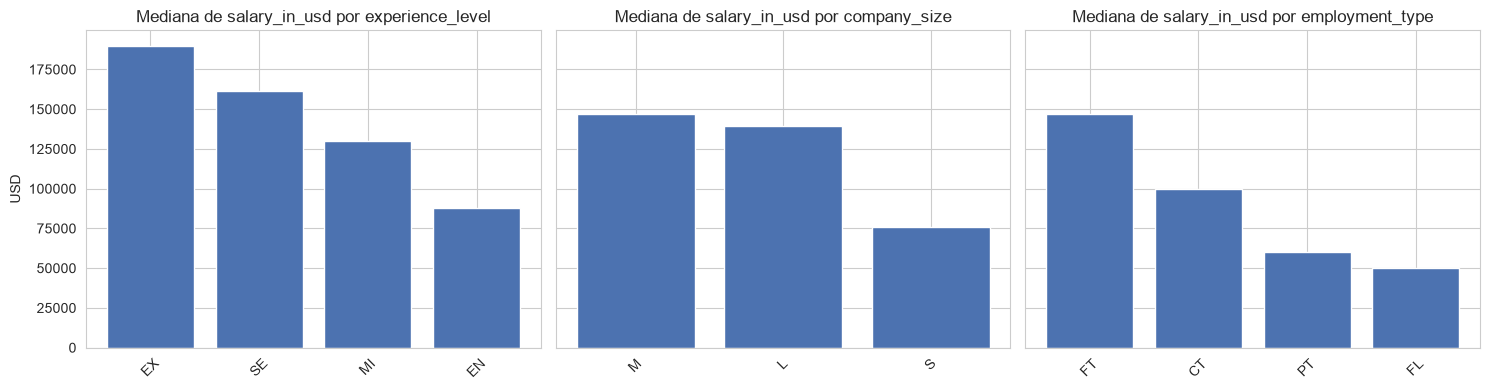

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, col in zip(axes, ["experience_level", "company_size", "employment_type"]):
    medianas = df.groupby(col)[target].median().sort_values(ascending=False)
    ax.bar(medianas.index.astype(str), medianas.values, color="#4C72B0")
    ax.set_title(f"Mediana de {target} por {col}")
    ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("USD")
plt.tight_layout()
plt.show()

**Interpretación:** `work_year` y `remote_ratio` (tratadas como numéricas) casi no
correlacionan linealmente con el target (0.03 y -0.06) — esperable, ya que son
categóricas de pocos niveles, no variables continuas. En cambio, `experience_level`
muestra una relación clara y monótona con la mediana salarial (EN < MI < SE < EX), y
`company_size` separa bien a las empresas pequeñas (`S`) del resto. Esto confirma que
las variables **categóricas** (seniority, cargo, ubicación) son las que realmente
explican el salario, más que cualquier variable numérica cruda — hay que codificarlas
bien (ver sección 5) y preferir modelos que manejen bien categóricas de alta
cardinalidad (p. ej. basados en árboles) al elegir el modelo baseline.


## 7. Validación de la partición temporal train / validación

In [20]:
resumen_anual = (
    df[df["work_year"].isin([2024, 2025])]
    .groupby("work_year")[target]
    .agg(n="count", media="mean", mediana="median", std="std")
    .round(0)
)
resumen_anual

,n,media,mediana,std
work_year,,,,
2024,62234,159600.0,148955.0,73581.0
2025,15875,155175.0,143100.0,77858.0


In [21]:
dist_experiencia = pd.crosstab(
    df[df["work_year"].isin([2024, 2025])]["work_year"],
    df[df["work_year"].isin([2024, 2025])]["experience_level"],
    normalize="index",
).round(3)
dist_experiencia

experience_level,EN,EX,MI,SE
work_year,,,,
2024,0.099,0.019,0.314,0.568
2025,0.098,0.023,0.316,0.563


**Interpretación:** 2024 (train propuesto, n=62.234) y 2025 (validación propuesta,
n=15.875) tienen medias y medianas de `salary_in_usd` muy similares (~3% de diferencia
en la mediana), y la composición por `experience_level` es prácticamente idéntica entre
ambos años. No hay señales de un quiebre estructural entre periodos.

**Decisión final de partición:** se confirma la estrategia temporal propuesta en
`docs/dataset.md` — **train = registros con `work_year` ≤ 2024 (62.234 filas), validación
= `work_year` = 2025 (15.875 filas)**. Replica el patrón de "entrenar con el pasado,
validar con el futuro" y es más honesta que un split aleatorio para un caso de uso donde
el modelo se usará para estimar salarios *hacia adelante*.


## 8. Conclusiones del EDA

**Filtros:**
- No se elimina ninguna fila por duplicados exactos: son observaciones repetidas
  legítimas (perfil combinado poco variado + salarios redondeados) y no cruzan entre
  `train` y `validación` porque el año forma parte de la comparación.
- No se eliminan atípicos altos (1.98% de las filas, > 337.354 USD): son salarios reales
  de roles senior/ejecutivos, relevantes para el caso de negocio.
- Se mantiene la exclusión de `salary` y `salary_currency` (`leakage_columns` en
  `configs/config.yaml`): son el target disfrazado en otra moneda/escala.

**Imputaciones:** ninguna — el dataset no tiene valores nulos (0 de 88.584 filas × 11
columnas, confirmado en este notebook y en `docs/dataset.md`).

**Transformaciones a implementar en el preprocesamiento (actividad 5):**
1. `job_title` (312 categorías, 194 con < 30 registros): agrupar las poco frecuentes en
   `"Other"` o usar encoding de frecuencia/target en vez de one-hot puro.
2. `employee_residence` / `company_location` (96 / 90 categorías, ~90% EE. UU.): agrupar
   en EE. UU. vs. resto (o top-N países + `"Other"`).
3. Evaluar `log1p(salary_in_usd)` como variante de target junto con la escala original;
   si se usa, **destransformar con `expm1` antes de calcular el RMSE en USD**.
4. `experience_level`, `employment_type`, `remote_ratio`, `company_size`: encoding
   categórico estándar (ordinal para `experience_level` dado su orden natural EN<MI<SE<EX,
   one-hot para el resto); sin necesidad de escalado si el modelo baseline es basado en
   árboles.

**Estrategia de partición train/validación (confirmada):** temporal — `train` con
`work_year` ≤ 2024 (62.234 filas), `validación` con `work_year` = 2025 (15.875 filas).
Validado en la sección 7: distribuciones de target y de `experience_level` consistentes
entre ambos periodos.
